In [2]:
with open("data.txt", "r", encoding="utf-8") as f:
    center_data = f.read()

center_data

'=== BO\'LIM 1: UMUMIY MA\'LUMOTLAR VA LOKATSIYA ===\nO\'quv markazi nomi: "Apex Academy" zamonaviy kasblar akademiyasi.\nIsh vaqti: Har kuni soat 09:00 dan 21:00 gacha. Yakshanba kuni ham markaz ochiq, lekin faqat self-study (mustaqil dars qilish) uchun soat 10:00 dan 18:00 gacha ishlaydi.\nManzil va Lokatsiya: Toshkent shahri, Chilonzor tumani, Bunyodkor ko\'chasi 42-uy. \nMo\'ljal: Chilonzor metrosi chiqishi, "Gafur Gulom" istirohat bog\'i ro\'parasi.\nAloqa telefoni: +998 (71) 200-00-00, Telegram bot: @apex_academy_bot.\n\n=== BO\'LIM 2: KURSLAR, NARXLAR VA DAVOMIYLIGI ===\nKURS: Koreys tili (Eps-Topik va Topik)\n- Davomiyligi: 6 oy. Haftada 3 marta, 2 soatdan.\n- Oylik to\'lovi: 650,000 so\'m.\n- Kurs yakunida EPS-TOPIK imtihoniga to\'liq tayyorgarlik ko\'riladi va sertifikat beriladi.\n\nKURS: Web Dasturlash (Full-Stack JavaScript)\n- Davomiyligi: 9 oy (3 oy Frontend, 3 oy Backend, 3 oy Amaliy loyiha va Portfolioga ishlash).\n- Grafik: Haftada 3 marta, 2 soatdan dars + har kuni b

In [3]:
from langchain_core.documents import Document as LangchainDocument

RAW_KNOWLEDGE_BASE = [
    LangchainDocument(page_content=center_data, metadata={"source": "data.txt"})
]

print(f"Hujjat soni: {len(RAW_KNOWLEDGE_BASE)}")

Hujjat soni: 1


In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

MARKDOWN_SEPARATORS = [
    "\n#{1,6} ",
    "```\n",
    "\n\\*\\*\\*+\n",
    "\n---+\n",
    "\n___+\n",
    "\n\n",
    "\n",
    " ",
    "",
]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
    add_start_index=True,
    strip_whitespace=True,
    separators=MARKDOWN_SEPARATORS
)

docs_processed = []
for doc in RAW_KNOWLEDGE_BASE:
    docs_processed += text_splitter.split_documents([doc])

docs_processed

[Document(metadata={'source': 'data.txt', 'start_index': 0}, page_content='=== BO\'LIM 1: UMUMIY MA\'LUMOTLAR VA LOKATSIYA ===\nO\'quv markazi nomi: "Apex Academy" zamonaviy kasblar akademiyasi.\nIsh vaqti: Har kuni soat 09:00 dan 21:00 gacha. Yakshanba kuni ham markaz ochiq, lekin faqat self-study (mustaqil dars qilish) uchun soat 10:00 dan 18:00 gacha ishlaydi.\nManzil va Lokatsiya: Toshkent shahri, Chilonzor tumani, Bunyodkor ko\'chasi 42-uy. \nMo\'ljal: Chilonzor metrosi chiqishi, "Gafur Gulom" istirohat bog\'i ro\'parasi.\nAloqa telefoni: +998 (71) 200-00-00, Telegram bot: @apex_academy_bot.\n\n=== BO\'LIM 2: KURSLAR, NARXLAR VA DAVOMIYLIGI ===\nKURS: Koreys tili (Eps-Topik va Topik)\n- Davomiyligi: 6 oy. Haftada 3 marta, 2 soatdan.\n- Oylik to\'lovi: 650,000 so\'m.\n- Kurs yakunida EPS-TOPIK imtihoniga to\'liq tayyorgarlik ko\'riladi va sertifikat beriladi.'),
 Document(metadata={'source': 'data.txt', 'start_index': 779}, page_content="KURS: Web Dasturlash (Full-Stack JavaScript)

100%|██████████| 3/3 [00:00<00:00, 754.37it/s]


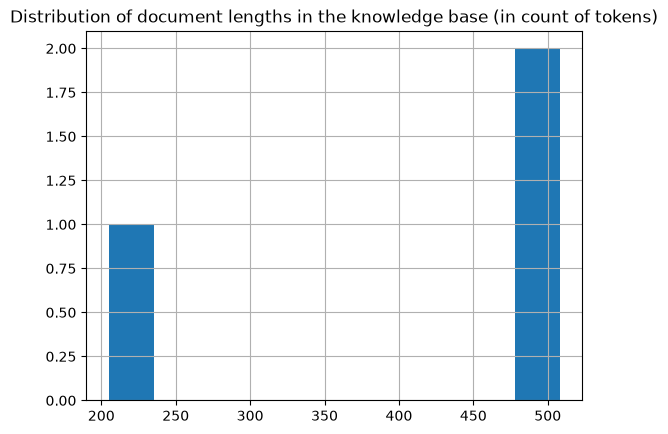

In [5]:
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Optional

EMBEDDING_MODEL_NAME = "thenlper/gte-small"


def split_documents(
    chunk_size: int,
    knowledge_base: List[LangchainDocument],
    tokenizer_name: Optional[str] = EMBEDDING_MODEL_NAME,
) -> List[LangchainDocument]:

    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        AutoTokenizer.from_pretrained(tokenizer_name),
        chunk_size=chunk_size,
        chunk_overlap=int(chunk_size / 10),
        add_start_index=True,
        strip_whitespace=True,
        separators=MARKDOWN_SEPARATORS,
    )

    docs_processed = []
    for doc in knowledge_base:
        docs_processed += text_splitter.split_documents([doc])

    unique_texts = {}
    docs_processed_unique = []
    for doc in docs_processed:
        if doc.page_content not in unique_texts:
            unique_texts[doc.page_content] = True
            docs_processed_unique.append(doc)

    return docs_processed_unique


docs_processed = split_documents(
    512, 
    RAW_KNOWLEDGE_BASE,
    tokenizer_name=EMBEDDING_MODEL_NAME,
)

tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)
lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs_processed)]
fig = pd.Series(lengths).hist()
plt.title("Distribution of document lengths in the knowledge base (in count of tokens)")
plt.show()